# **1. Perkenalan Dataset**

Notebook ini mengikuti template eksperimen MSML untuk dataset **Employee Attrition**.

Dataset yang digunakan adalah dataset tabular employee attrition sintetis dan reproducible. Dataset memuat informasi karyawan seperti usia, pendapatan bulanan, masa kerja, jarak rumah, kepuasan kerja, lembur, departemen, pendidikan, dan target `attrition`.

Tujuan eksperimen ini adalah memahami karakteristik data, melakukan EDA, membersihkan data, menangani missing value/duplikasi, melakukan encoding dan scaling, lalu menghasilkan dataset siap latih untuk tahap modelling dan Workflow CI.

# **2. Import Library**

Pada tahap ini, pustaka Python yang dibutuhkan untuk data loading, EDA, dan preprocessing diimpor terlebih dahulu.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# **3. Memuat Dataset**

Pada tahap ini, dataset dimuat dari folder `employee_attrition_raw`. Variabel `url` tetap digunakan sebagai path sumber data agar alur loading mudah terlihat seperti pada template.

In [2]:
url = "../employee_attrition_raw/employee_attrition_raw.csv"
df = pd.read_csv(url)

display(df.head())
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

,employee_id,age,monthly_income,years_at_company,distance_from_home,job_satisfaction,overtime,department,education,attrition
0,E0001,29,6027.0,0,18,2.0,Yes,Operations,Master,Yes
1,E0002,23,5455.0,2,14,2.0,No,Sales,Bachelor,No
2,E0003,56,10386.0,13,15,4.0,No,Operations,High School,No
3,E0004,31,6119.0,6,22,1.0,Yes,Sales,Master,Yes
4,E0005,24,6440.0,3,8,4.0,Yes,Research,Bachelor,No


Jumlah baris: 365
Jumlah kolom: 10


In [3]:
display(df.info())
display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         365 non-null    object 
 1   age                 365 non-null    int64  
 2   monthly_income      361 non-null    float64
 3   years_at_company    365 non-null    int64  
 4   distance_from_home  365 non-null    int64  
 5   job_satisfaction    363 non-null    float64
 6   overtime            365 non-null    object 
 7   department          362 non-null    object 
 8   education           365 non-null    object 
 9   attrition           365 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 28.6+ KB


None

,employee_id,age,monthly_income,years_at_company,distance_from_home,job_satisfaction,overtime,department,education,attrition
count,365,365.000000,361.000000,365.000000,365.000000,363.000000,365,362,365,365
unique,360,NaN,NaN,NaN,NaN,NaN,2,5,4,2
top,E0001,NaN,NaN,NaN,NaN,NaN,No,Research,Bachelor,No
freq,2,NaN,NaN,NaN,NaN,NaN,244,129,165,283
mean,NaN,40.841096,8320.063712,9.378082,17.512329,2.520661,NaN,NaN,NaN,NaN
std,NaN,10.997350,1708.943689,6.125479,9.084644,1.127990,NaN,NaN,NaN,NaN
min,NaN,22.000000,4378.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,31.000000,7070.000000,4.000000,10.000000,2.000000,NaN,NaN,NaN,NaN
50%,NaN,41.000000,8249.000000,9.000000,18.000000,3.000000,NaN,NaN,NaN,NaN
75%,NaN,51.000000,9586.000000,14.000000,25.000000,4.000000,NaN,NaN,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, EDA dilakukan untuk memahami struktur data, missing value, duplikasi, distribusi target, dan pola awal beberapa fitur penting terhadap target attrition.

In [4]:
eda_summary = pd.DataFrame({
    "missing_value": df.isna().sum(),
    "missing_ratio": df.isna().mean(),
    "unique_value": df.nunique(),
    "dtype": df.dtypes.astype(str),
})
display(eda_summary)
print(f"Jumlah duplikasi employee_id: {df.duplicated(subset=['employee_id']).sum()}")
print(f"Jumlah duplikasi seluruh baris: {df.duplicated().sum()}")

,missing_value,missing_ratio,unique_value,dtype
employee_id,0,0.000000,360,object
age,0,0.000000,38,int64
monthly_income,4,0.010959,347,float64
years_at_company,0,0.000000,23,int64
distance_from_home,0,0.000000,32,int64
job_satisfaction,2,0.005479,4,float64
overtime,0,0.000000,2,object
department,3,0.008219,5,object
education,0,0.000000,4,object
attrition,0,0.000000,2,object


Jumlah duplikasi employee_id: 5
Jumlah duplikasi seluruh baris: 5


attrition
No     283
Yes     82
Name: count, dtype: int64

attrition
No     0.775342
Yes    0.224658
Name: ratio, dtype: float64

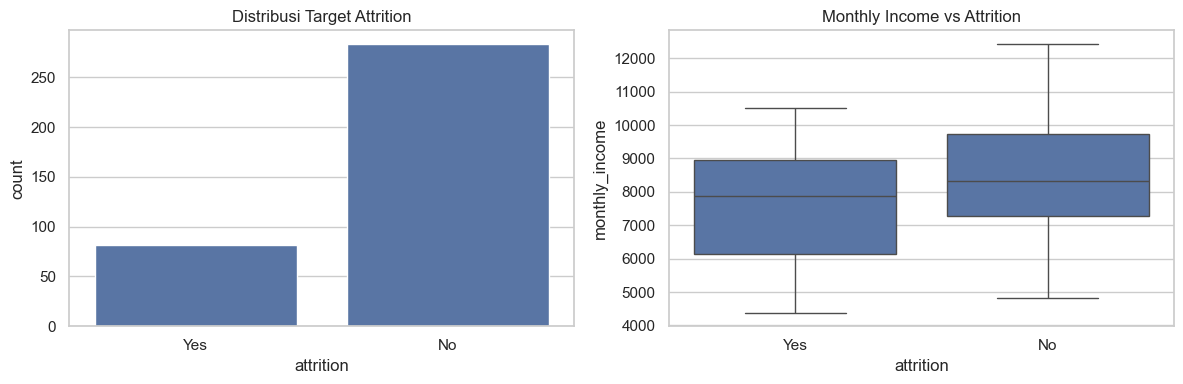

In [5]:
display(df["attrition"].value_counts())
display(df["attrition"].value_counts(normalize=True).rename("ratio"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="attrition", ax=axes[0])
axes[0].set_title("Distribusi Target Attrition")
sns.boxplot(data=df, x="attrition", y="monthly_income", ax=axes[1])
axes[1].set_title("Monthly Income vs Attrition")
plt.tight_layout()
plt.show()

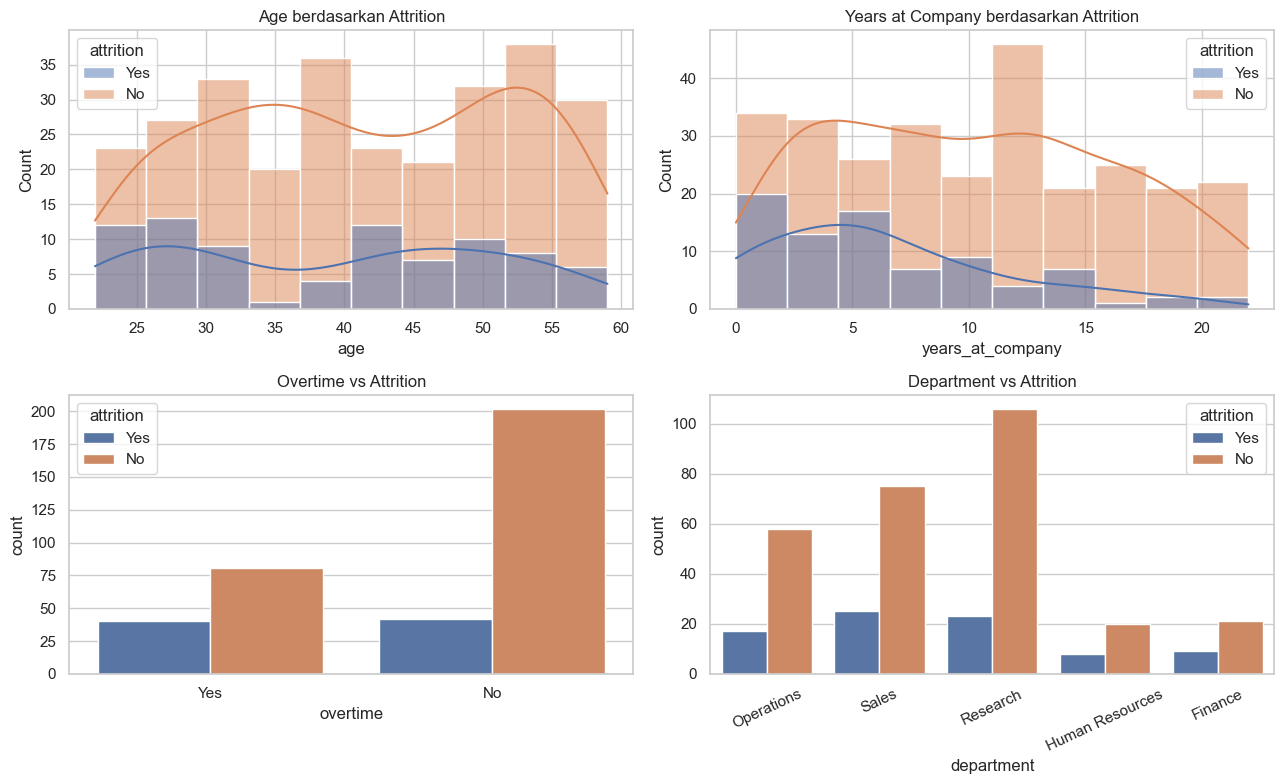

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(data=df, x="age", hue="attrition", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age berdasarkan Attrition")
sns.histplot(data=df, x="years_at_company", hue="attrition", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Years at Company berdasarkan Attrition")
sns.countplot(data=df, x="overtime", hue="attrition", ax=axes[1, 0])
axes[1, 0].set_title("Overtime vs Attrition")
sns.countplot(data=df, x="department", hue="attrition", ax=axes[1, 1])
axes[1, 1].set_title("Department vs Attrition")
axes[1, 1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Tahap preprocessing disesuaikan dengan karakteristik dataset tabular:

1. Menyeragamkan nama kolom.
2. Menghapus duplikasi berdasarkan `employee_id`.
3. Menghapus kolom identifier `employee_id` agar tidak menjadi fitur model.
4. Membersihkan whitespace pada fitur kategorikal.
5. Mengubah target `attrition` menjadi numerik: `No=0`, `Yes=1`.
6. Melakukan imputasi median untuk fitur numerik.
7. Melakukan imputasi modus dan one-hot encoding untuk fitur kategorikal.
8. Melakukan standardisasi fitur numerik.
9. Membagi data menjadi train dan test secara stratified.
10. Mengekspor dataset siap latih melalui script otomatis `automate_Panji.py`.

In [7]:
numeric_features = [
    "age",
    "monthly_income",
    "years_at_company",
    "distance_from_home",
    "job_satisfaction",
]
categorical_features = ["overtime", "department", "education"]
target = "attrition"

clean = df.copy()
clean.columns = [column.strip().lower() for column in clean.columns]
clean = clean.drop_duplicates(subset=["employee_id"]).drop(columns=["employee_id"])

for column in categorical_features + [target]:
    clean[column] = clean[column].astype("object")
    clean[column] = clean[column].where(clean[column].notna(), None)
    clean[column] = clean[column].map(lambda value: value.strip() if isinstance(value, str) else value)

clean[target] = clean[target].map({"No": 0, "Yes": 1, "no": 0, "yes": 1})
clean = clean.dropna(subset=[target])
clean[target] = clean[target].astype(int)

display(clean.head())
print(clean.shape)
display(clean[target].value_counts(normalize=True).rename("ratio"))

,age,monthly_income,years_at_company,distance_from_home,job_satisfaction,overtime,department,education,attrition
0,29,6027.0,0,18,2.0,Yes,Operations,Master,1
1,23,5455.0,2,14,2.0,No,Sales,Bachelor,0
2,56,10386.0,13,15,4.0,No,Operations,High School,0
3,31,6119.0,6,22,1.0,Yes,Sales,Master,1
4,24,6440.0,3,8,4.0,Yes,Research,Bachelor,0


(360, 9)


attrition
0    0.777778
1    0.222222
Name: ratio, dtype: float64

In [8]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

X = clean[numeric_features + categorical_features]
y = clean[target]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

encoded_features = preprocessor.named_transformers_["categorical"].named_steps["encoder"].get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + encoded_features

train_ready = pd.DataFrame(X_train_ready, columns=feature_names, index=X_train.index)
train_ready[target] = y_train.to_numpy()
train_ready["split"] = "train"

test_ready = pd.DataFrame(X_test_ready, columns=feature_names, index=X_test.index)
test_ready[target] = y_test.to_numpy()
test_ready["split"] = "test"

combined_ready = pd.concat([train_ready, test_ready], axis=0).sort_index().reset_index(drop=True)

display(combined_ready.head())
print(f"Train shape: {train_ready.shape}")
print(f"Test shape: {test_ready.shape}")
print(f"Combined shape: {combined_ready.shape}")

,age,monthly_income,years_at_company,distance_from_home,job_satisfaction,overtime_No,overtime_Yes,department_Finance,department_Human Resources,department_Operations,department_Research,department_Sales,department_None,education_Bachelor,education_Doctor,education_High School,education_Master,attrition,split
0,-1.136851,-1.401322,-1.564358,0.063739,-0.505697,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,train
1,-1.694150,-1.736933,-1.241162,-0.375943,-0.505697,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,train
2,1.370994,1.156240,0.536415,-0.266022,1.281306,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,train
3,-0.951085,-1.347343,-0.594770,0.503420,-1.399198,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1,train
4,-1.601267,-1.159002,-1.079564,-1.035465,1.281306,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0,train


Train shape: (288, 19)
Test shape: (72, 19)
Combined shape: (360, 19)


In [9]:
output_dir = Path("employee_attrition_preprocessing")
output_dir.mkdir(parents=True, exist_ok=True)

combined_ready.to_csv(output_dir / "employee_attrition_preprocessed.csv", index=False)
train_ready.reset_index(drop=True).to_csv(output_dir / "train.csv", index=False)
test_ready.reset_index(drop=True).to_csv(output_dir / "test.csv", index=False)
joblib.dump(preprocessor, output_dir / "fitted_preprocessor.joblib")

metadata = {
    "rows_raw": int(len(df)),
    "rows_after_cleaning": int(len(clean)),
    "train_rows": int(len(train_ready)),
    "test_rows": int(len(test_ready)),
    "target": target,
    "positive_rate": float(clean[target].mean()),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "encoded_feature_count": len(feature_names),
    "feature_names": feature_names,
}
(output_dir / "preprocessing_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Dataset siap latih tersimpan di: {output_dir.resolve()}")
print(json.dumps(metadata, indent=2))

Dataset siap latih tersimpan di: C:\Users\62857\Documents\Pijak\4\Eksperimen_SML_Panji\preprocessing\employee_attrition_preprocessing
{
  "rows_raw": 365,
  "rows_after_cleaning": 360,
  "train_rows": 288,
  "test_rows": 72,
  "target": "attrition",
  "positive_rate": 0.2222222222222222,
  "numeric_features": [
    "age",
    "monthly_income",
    "years_at_company",
    "distance_from_home",
    "job_satisfaction"
  ],
  "categorical_features": [
    "overtime",
    "department",
    "education"
  ],
  "encoded_feature_count": 17,
  "feature_names": [
    "age",
    "monthly_income",
    "years_at_company",
    "distance_from_home",
    "job_satisfaction",
    "overtime_No",
    "overtime_Yes",
    "department_Finance",
    "department_Human Resources",
    "department_Operations",
    "department_Research",
    "department_Sales",
    "department_None",
    "education_Bachelor",
    "education_Doctor",
    "education_High School",
    "education_Master"
  ]
}


## Konversi ke Script Otomatis

Tahapan preprocessing manual di atas dikonversi ke `automate_Panji.py`. Script ini digunakan oleh GitHub Actions agar dataset preprocessing dapat dibuat ulang setiap workflow berjalan.

In [10]:
from automate_Panji import load_data, preprocess_data, save_preprocessed_data

raw_data = load_data(url)
combined_auto, train_auto, test_auto, fitted_preprocessor, auto_metadata = preprocess_data(raw_data)
save_preprocessed_data(
    combined=combined_auto,
    train_ready=train_auto,
    test_ready=test_auto,
    preprocessor=fitted_preprocessor,
    metadata=auto_metadata,
    output_dir="employee_attrition_preprocessing",
)

print("Automated preprocessing selesai.")
print(json.dumps(auto_metadata, indent=2))

Automated preprocessing selesai.
{
  "rows_raw": 365,
  "rows_after_cleaning": 360,
  "train_rows": 288,
  "test_rows": 72,
  "target": "attrition",
  "positive_rate": 0.2222222222222222,
  "numeric_features": [
    "age",
    "monthly_income",
    "years_at_company",
    "distance_from_home",
    "job_satisfaction"
  ],
  "categorical_features": [
    "overtime",
    "department",
    "education"
  ],
  "encoded_feature_count": 17,
  "feature_names": [
    "age",
    "monthly_income",
    "years_at_company",
    "distance_from_home",
    "job_satisfaction",
    "overtime_No",
    "overtime_Yes",
    "department_Finance",
    "department_Human Resources",
    "department_Operations",
    "department_Research",
    "department_Sales",
    "department_None",
    "education_Bachelor",
    "education_Doctor",
    "education_High School",
    "education_Master"
  ]
}
